# Student Grade Prediction using Machine Learning
A machine learning project predicting final student performance using demographic and behavioral features. This project explores feature importance, preprocessing techniques, and model evaluation using scikit-learn.

## Import Data First

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

student_mat = pd.read_csv('student-mat.csv')


#G3 is the final student grade so we're dropping G3 and making it the target
final_grade_label = student_mat['G3'] #y
final_grade_features = student_mat.drop(columns=['G3']) #X

X_train, X_test , y_train, y_test = train_test_split(
    final_grade_features,
    final_grade_label,
    test_size=0.2,
    random_state=42
    )

In [8]:
student_mat.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences_G1,absences_G2,absences_G3,G1,G2,G3
count,383.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,382.000000,386.000000,381.000000,395.000000,395.000000,395.000000
mean,16.699739,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,0.672775,1.093264,4.173228,10.908861,10.713924,10.415190
std,1.280615,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,1.300209,1.465307,4.897520,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,0.000000,1.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,1.000000,2.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,12.000000,11.000000,36.000000,19.000000,19.000000,20.000000


In [9]:
student_mat.isnull().sum() #(nulls in age and absences_G1, absences_G2, and absences_G3)

school          0
sex             0
age            12
address         0
famsize         0
Pstatus         0
Medu            0
Fedu            0
Mjob            0
Fjob            0
reason          0
guardian        0
traveltime      0
studytime       0
failures        0
schoolsup       0
famsup          0
paid            0
activities      0
nursery         0
higher          0
internet        0
romantic        0
famrel          0
freetime        0
goout           0
Dalc            0
Walc            0
health          0
absences_G1    13
absences_G2     9
absences_G3    14
G1              0
G2              0
G3              0
dtype: int64

In [10]:
student_mat.dtypes

school          object
sex             object
age            float64
address         object
famsize         object
Pstatus         object
Medu             int64
Fedu             int64
Mjob            object
Fjob            object
reason          object
guardian        object
traveltime       int64
studytime        int64
failures         int64
schoolsup       object
famsup          object
paid            object
activities      object
nursery         object
higher          object
internet        object
romantic        object
famrel           int64
freetime         int64
goout            int64
Dalc             int64
Walc             int64
health           int64
absences_G1    float64
absences_G2    float64
absences_G3    float64
G1               int64
G2               int64
G3               int64
dtype: object

In [12]:
#correlation matrix for all numeric values
numeric_data = student_mat.select_dtypes(include=[np.number])

correlation_matrix = numeric_data.corr()
print(correlation_matrix)

#G2 and G1 are strongly correlated hence strong predictors but nothing else really is

                  age      Medu      Fedu  traveltime  studytime  failures  \
age          1.000000 -0.173685 -0.169510    0.071326  -0.008327  0.245332   
Medu        -0.173685  1.000000  0.623455   -0.171639   0.064944 -0.236680   
Fedu        -0.169510  0.623455  1.000000   -0.158194  -0.009175 -0.250408   
traveltime   0.071326 -0.171639 -0.158194    1.000000  -0.100909  0.092239   
studytime   -0.008327  0.064944 -0.009175   -0.100909   1.000000 -0.173563   
failures     0.245332 -0.236680 -0.250408    0.092239  -0.173563  1.000000   
famrel       0.052099 -0.003914 -0.001370   -0.016808   0.039731 -0.044337   
freetime     0.005806  0.030891 -0.012846   -0.017025  -0.143198  0.091987   
goout        0.118420  0.064094  0.043105    0.028540  -0.063904  0.124561   
Dalc         0.137903  0.019834  0.002386    0.138325  -0.196019  0.136047   
Walc         0.119580 -0.047123 -0.012631    0.134116  -0.253785  0.141962   
health      -0.063560 -0.046878  0.014742    0.007501  -0.075616

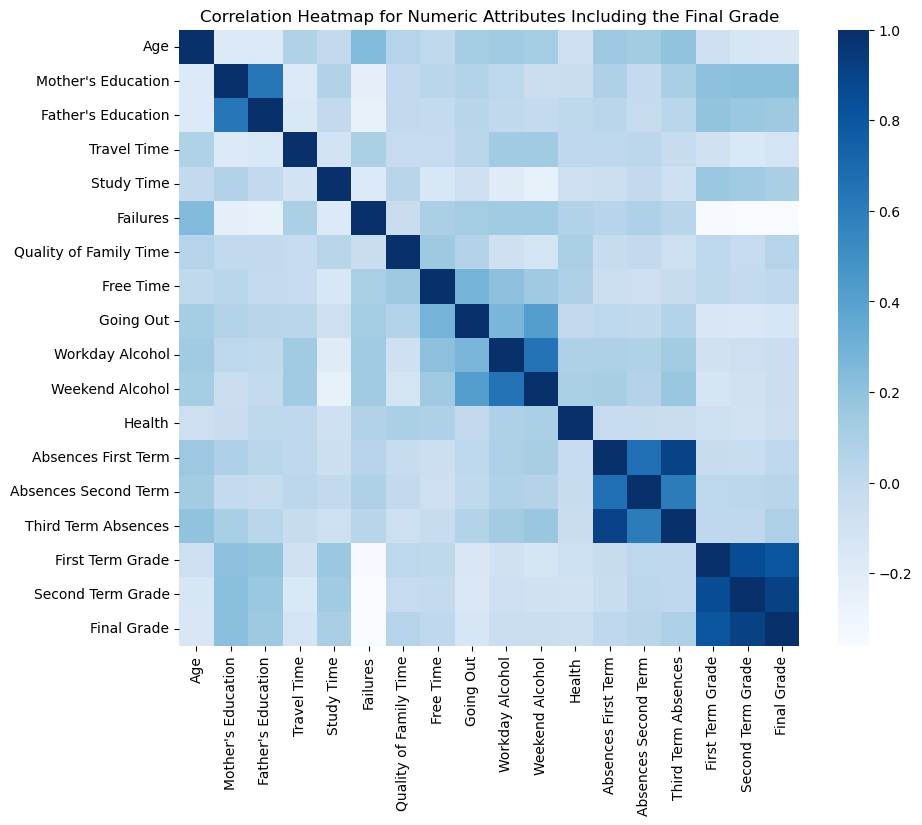

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = correlation_matrix.rename(
    index={'age': "Age", 'Medu': "Mother's Education", 'Fedu': "Father's Education", 'traveltime': "Travel Time", 'studytime': "Study Time",
           'failures': "Failures", 'famrel': "Quality of Family Time", 'freetime': "Free Time", 'goout': "Going Out", 'Dalc': "Workday Alcohol",
           'Walc': "Weekend Alcohol", 'health': "Health", 'absences_G1': "Absences First Term", 'absences_G2': "Absences Second Term",
           'absences_G3': "Third Term Absences", 'G1': "First Term Grade", 'G2': "Second Term Grade", 'G3': "Final Grade"},
    columns={'age': "Age", 'Medu': "Mother's Education", 'Fedu': "Father's Education", 'traveltime': "Travel Time", 'studytime': "Study Time",
           'failures': "Failures", 'famrel': "Quality of Family Time", 'freetime': "Free Time", 'goout': "Going Out", 'Dalc': "Workday Alcohol",
           'Walc': "Weekend Alcohol", 'health': "Health", 'absences_G1': "Absences First Term", 'absences_G2': "Absences Second Term",
           'absences_G3': "Third Term Absences", 'G1': "First Term Grade", 'G2': "Second Term Grade", 'G3': "Final Grade"}
)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='Blues')
plt.title("Correlation Heatmap for Numeric Attributes Including the Final Grade")
#plt.xticks(rotation=45)
plt.show()


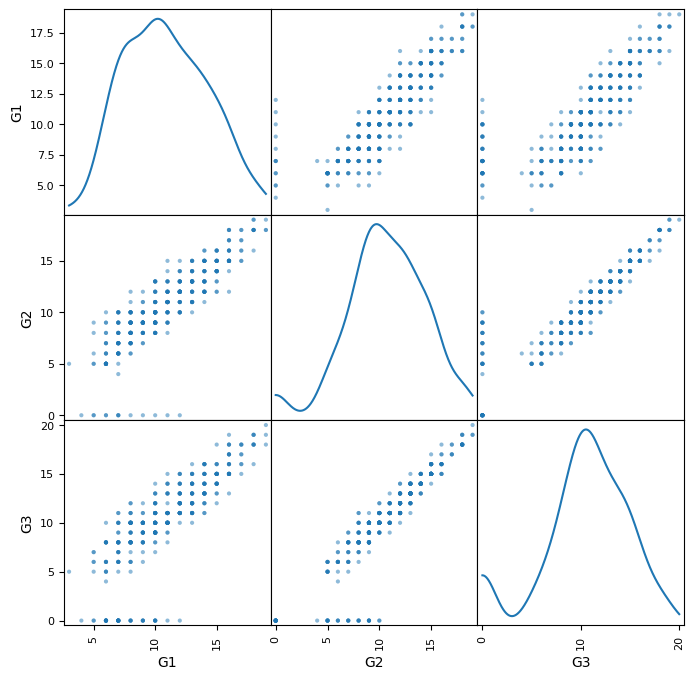

In [14]:
#scatter matrix for all grades

from pandas.plotting import scatter_matrix

grades_df = student_mat[['G1', 'G2', 'G3']]
scatter_matrix(grades_df, figsize=(8, 8), diagonal='kde')
plt.show()

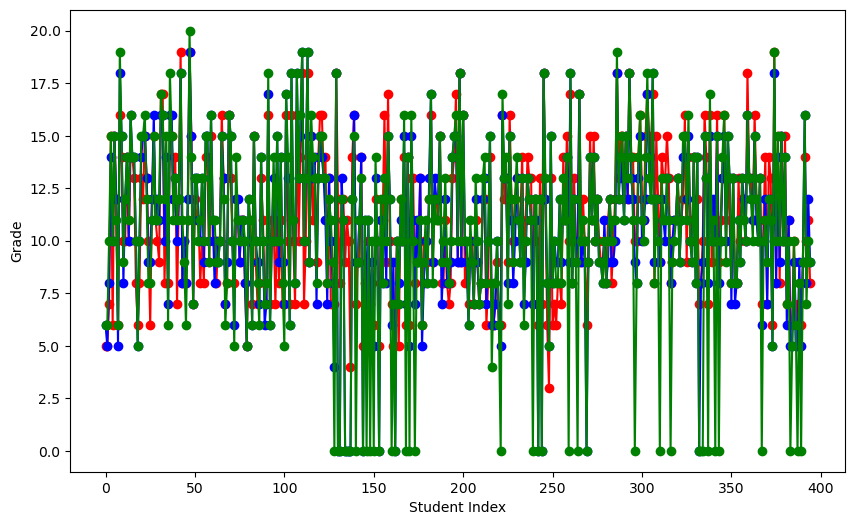

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(student_mat.index, student_mat['G1'], label='G1', marker='o', color='red')
plt.plot(student_mat.index, student_mat['G2'], label='G2', marker='o', color='blue')
plt.plot(student_mat.index, student_mat['G3'], label='G3', marker='o', color='green')
plt.xlabel('Student Index')
plt.ylabel('Grade')
plt.show()

#this is just a mess...was trying to visualize and see patterns but no...we'll have to include more

C:\Users\amybr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


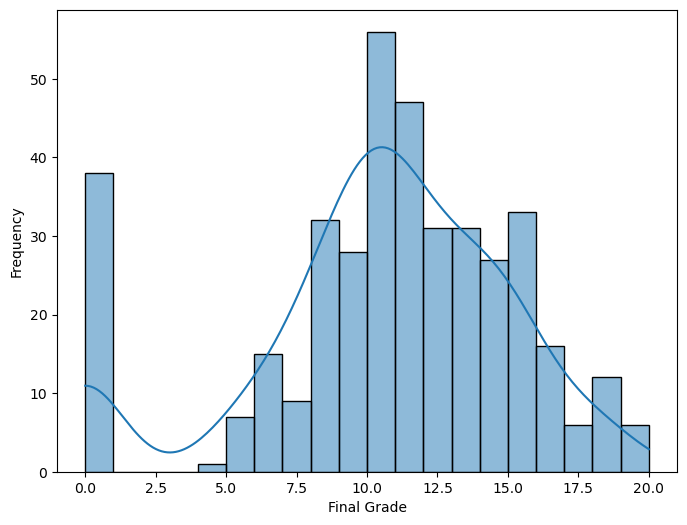

In [16]:
plt.figure(figsize=(8, 6))
sns.histplot(student_mat['G3'], kde=True, bins=20)
plt.xlabel('Final Grade')
plt.ylabel('Frequency')
plt.show()
#overall dist of final grade - normally distributed except the outliers at or close to zero 

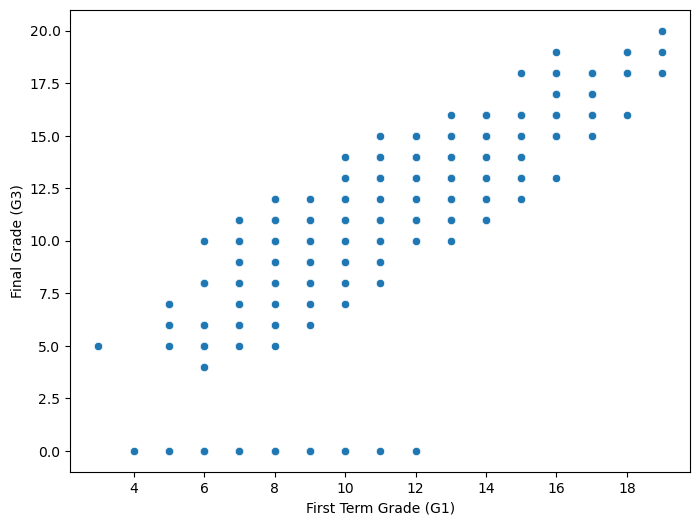

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=student_mat['G1'], y=student_mat['G3'])
plt.xlabel('First Term Grade (G1)')
plt.ylabel('Final Grade (G3)')
plt.show()

#G1 is a good predictor of G3 but we already knew that

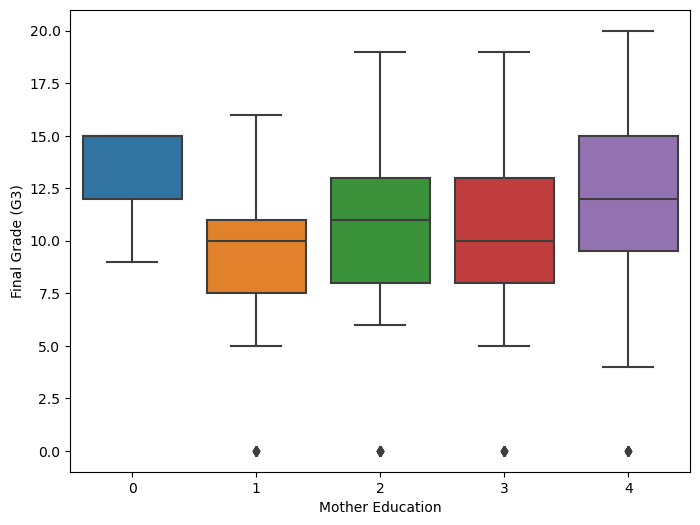

In [146]:
#G3 by mom ed

plt.figure(figsize=(8, 6))
sns.boxplot(x='Medu', y='G3', data=student_mat)
plt.xlabel('Mother Education')
plt.ylabel('Final Grade (G3)')
plt.show()

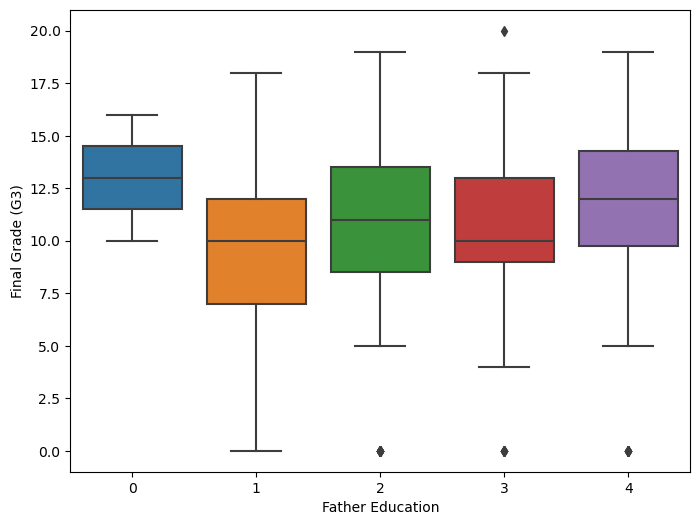

In [19]:
#G3 by dad ed

plt.figure(figsize=(8, 6))
sns.boxplot(x='Fedu', y='G3', data=student_mat)
plt.xlabel('Father Education')
plt.ylabel('Final Grade (G3)')
plt.show()

In [20]:
#making yes/no cats binary to see correlation with G3

binary_columns = ['higher', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'internet', 'romantic']

for col in binary_columns:
    student_mat[col + '_binary'] = student_mat[col].map({'yes':1, 'no':0})

binary_corr = {}
for col in binary_columns:
    binary_col = col + '_binary'
    binary_corr[col] = student_mat[binary_col].corr(student_mat['G3'])

binary_corr_df = pd.DataFrame.from_dict(binary_corr, orient='index', columns=['Correlations with G3'])

print(binary_corr_df)

#and none have a great correlation

            Correlations with G3
higher                  0.182465
schoolsup              -0.082788
famsup                 -0.039157
paid                    0.101996
activities              0.016100
nursery                 0.051568
internet                0.098483
romantic               -0.129970


In [21]:
#changed medu and fedu to _higher ==4 to see correlation between that and G3

student_mat['medu_higher'] = (student_mat['Medu'] == 4).astype(int)
student_mat['fedu_higher'] = (student_mat['Fedu'] == 4).astype(int)

corr_medu = student_mat['medu_higher'].corr(student_mat['G3'])
corr_fedu = student_mat['fedu_higher'].corr(student_mat['G3'])

print(corr_medu)
print(corr_fedu)

#Medu & Fedu ==4 isn't much different than using all levels of education

0.20755164348183947
0.11756943852306583


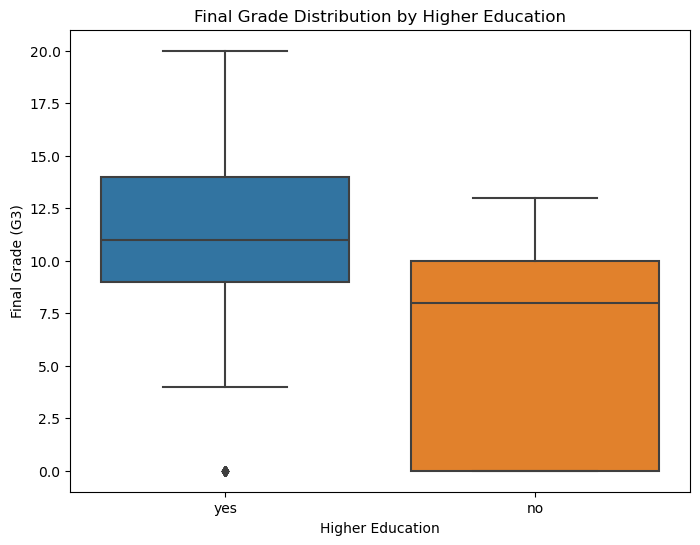

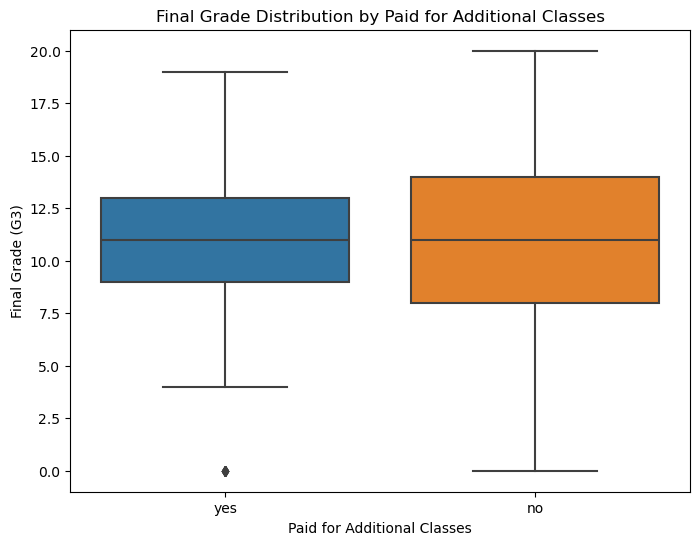

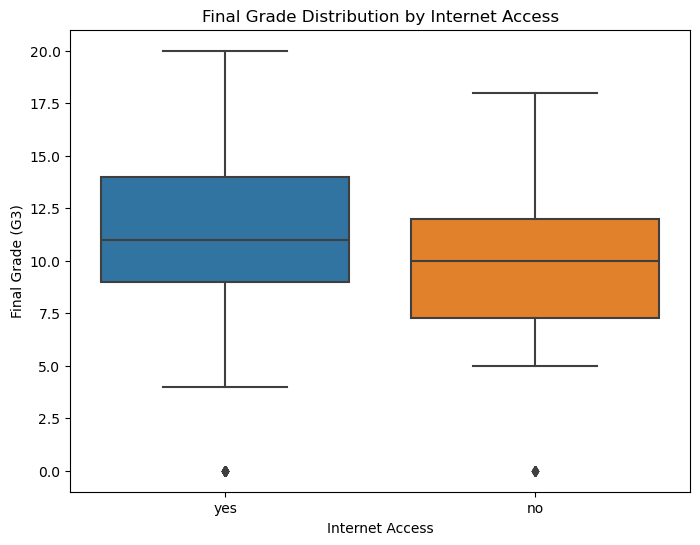

In [178]:
label_mapping = {
    'higher': "Higher Education",
    'internet': "Internet Access",
    'paid': "Paid for Additional Classes"
}

categorical_columns = ['higher', 'paid', 'internet']

for col in categorical_columns:
    plt.figure(figsize=(8, 6))
    renamed_label = label_mapping.get(col, col)
    ax_renamed_label = sns.boxplot(x=student_mat[col], y=student_mat['G3'], order=['yes', 'no'])
    ax_renamed_label.set_xlabel(renamed_label)
    plt.title(f"Final Grade Distribution by {renamed_label}")
    plt.xlabel(renamed_label)
    plt.ylabel("Final Grade (G3)")
    plt.show()

In [24]:
#created lists of columns
numeric_columns = ['absences_G1', 'absences_G2', 'absences_G3', 'G1', 'G2', 'studytime']
categorical_columns = ['paid', 'internet', 'higher']
ordinal_columns = ['Medu', 'Fedu']    

In [26]:
### ENTER CODE HERE ###
from sklearn.base import BaseEstimator, TransformerMixin

class FinalProjectTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, drop_grades=True):           
        self.drop_grades = drop_grades   

    def fit(self, X, y=None):                                
        return self   

    def transform(self,X, y=None):
        X = X.copy()
        X['absences_sum'] = X['absences_G1'] + X['absences_G2'] + X['absences_G3']
        X = X.drop(columns=['absences_G1', 'absences_G2', 'absences_G3'])

        if self.drop_grades:
            X = X.drop(columns=['G1', 'G2'])

        return X       

In [28]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

#numeric pipeline keeping all grades
numeric_pipeline_with_grades = make_pipeline(
    SimpleImputer(strategy="mean").set_output(transform="pandas"),
    FinalProjectTransformer(drop_grades=False),
    StandardScaler())

#numeric pipelin dropping G1 and G2
numeric_pipeline_without_grades = make_pipeline(
    SimpleImputer(strategy="mean").set_output(transform="pandas"),
    FinalProjectTransformer(drop_grades=True),
    StandardScaler())

#categorical pipeline
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent").set_output(transform="pandas"),
    OneHotEncoder(drop='first', sparse_output=False))

#ordinal pipeline
ordinal_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent").set_output(transform="pandas"),
    OrdinalEncoder())

#Column Transformer with all grades
column_transformer_with_grades = ColumnTransformer([
    ("num", numeric_pipeline_with_grades, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns),
    ("ord", ordinal_pipeline, ordinal_columns)])

#Column Transformer dropping G1 and G2
column_transformer_without_grades = ColumnTransformer([
    ("num", numeric_pipeline_without_grades, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns),
    ("ord", ordinal_pipeline, ordinal_columns)])

#fit and transform
X_train_transformed_with_grades = column_transformer_with_grades.fit_transform(X_train)
X_train_transformed_without_grades = column_transformer_without_grades.fit_transform(X_train)

#confirm dropping G1 and G2 really dropped and it did!
print(X_train_transformed_with_grades.shape)
print(X_train_transformed_without_grades.shape)    

(316, 9)
(316, 7)


In [30]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

#initialize models
lin_reg = LinearRegression()
svm_reg = SVR()
lasso_reg = Lasso()

#compare models with cross validation including all grades
cv_scores_lin_reg_with_grades = cross_val_score(lin_reg, X_train_transformed_with_grades, y_train, cv=3, scoring="neg_root_mean_squared_error")
cv_scores_lin_reg_without_grades = cross_val_score(lin_reg, X_train_transformed_without_grades, y_train, cv=3, scoring="neg_root_mean_squared_error")
cv_scores_svm_with_grades = cross_val_score(svm_reg, X_train_transformed_with_grades, y_train, cv=3, scoring="neg_root_mean_squared_error")
cv_scores_svm_without_grades = cross_val_score(svm_reg, X_train_transformed_without_grades, y_train, cv=3, scoring="neg_root_mean_squared_error")
cv_scores_lasso_with_grades = cross_val_score(lasso_reg, X_train_transformed_with_grades, y_train, cv=3, scoring="neg_root_mean_squared_error")
cv_scores_lasso_without_grades = cross_val_score(lasso_reg, X_train_transformed_without_grades, y_train, cv=3, scoring="neg_root_mean_squared_error")

#cross validation RMSE means
rmse_lin_reg_with_grades = np.mean(np.abs(cv_scores_lin_reg_with_grades))
rmse_lin_reg_without_grades = np.mean(np.abs(cv_scores_lin_reg_without_grades))
rmse_svm_with_grades = np.mean(np.abs(cv_scores_svm_with_grades))
rmse_svm_without_grades = np.mean(np.abs(cv_scores_svm_without_grades))
rmse_lasso_with_grades = np.mean(np.abs(cv_scores_lasso_with_grades))
rmse_lasso_without_grades = np.mean(np.abs(cv_scores_lasso_without_grades))

print(rmse_lin_reg_with_grades)
print(rmse_lin_reg_without_grades)
print(rmse_svm_with_grades)
print(rmse_svm_without_grades)
print(rmse_lasso_with_grades)
print(rmse_lasso_without_grades)

#when G1 and G2 are included, the models RMSE is lower becuse they are strong predictors on the final grade (G3). Higher RMSE scores without G1 and G2
#make it more difficult for G3 alone to predict more challenging. Because of this, using G1 and G2 we are able to predict G3 earlier.

1.9128465704025583
4.555412631357641
2.2882451128748795
4.516663806416392
2.1690514380657917
4.574116987769159


In [32]:
#fine-tuning
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

svr = SVR()

param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.10, 1],
    'kernel': ['rbf', 'linear']}

#initialize
grid_search = GridSearchCV(svr, param_grid, scoring="neg_root_mean_squared_error", cv=3, verbose=1)

#fit GridSearch with all grades
grid_search.fit(X_train_transformed_with_grades, y_train)

best_params_with_grades = grid_search.best_params_
best_score_with_grades = grid_search.best_score_
print(best_params_with_grades)
print(best_score_with_grades)

#fit GridSearch dropping G1 and G2
grid_search.fit(X_train_transformed_without_grades, y_train)

best_params_without_grades = grid_search.best_params_
best_score_without_grades = grid_search.best_score_
print(best_params_without_grades)
print(best_score_without_grades)

#model gets RMSE of 1.86, so pretty accurate predictions when all grades are provided. when dropping G1 and G2 the RMSE increases to 4.45 so it's more
#difficult to predict G3 without those.

#the best SVR model with C=10 and epsilon=1 performs better when all grades are included, when we remove G1 and G2 those are still the best hyperP's but
#model deteriorates which we knew would happen since we lost key predictors

Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
-1.9006858452003987
Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}
-4.516663806416392


In [34]:
#test set performance
#when dropping G1 and G2 SVR outperforms the other models meaning itse ability to capture non-linear relationships helps and may generalize better when
#predicting the final grade earlier in the timeline when G1 and G2 are not yet available so using SVR
from sklearn.metrics import mean_squared_error, r2_score

#initialize best models
best_svr_model_with_grades = SVR(**best_params_with_grades)
best_svr_model_without_grades = SVR(**best_params_without_grades)

#fit
best_svr_model_with_grades.fit(X_train_transformed_with_grades, y_train)
best_svr_model_without_grades.fit(X_train_transformed_without_grades, y_train)

#transform
X_test_transformed_with_grades = column_transformer_with_grades.transform(X_test)
X_test_transformed_without_grades = column_transformer_without_grades.transform(X_test)

#predict
y_test_pred_with_grades = best_svr_model_with_grades.predict(X_test_transformed_with_grades)
y_test_pred_without_grades = best_svr_model_without_grades.predict(X_test_transformed_without_grades)

#evaluate
rmse_with_grades = mean_squared_error(y_test, y_test_pred_with_grades, squared=False)
r2_with_grades = r2_score(y_test, y_test_pred_with_grades)

rmse_without_grades = mean_squared_error(y_test, y_test_pred_without_grades, squared=False)
r2_without_grades = r2_score(y_test, y_test_pred_without_grades)

print(rmse_with_grades)
print(r2_with_grades)
print(rmse_without_grades)
print(r2_without_grades)

2.037025267808243
0.7976365580901872
4.532715684887438
-0.001973378136103987


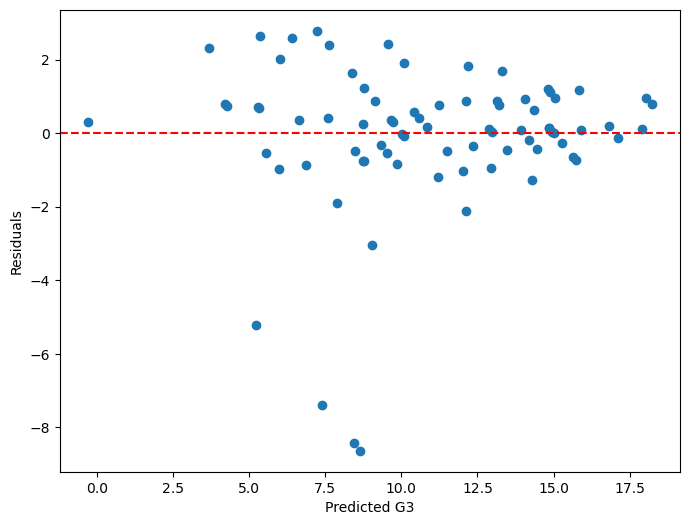

In [35]:
#residual plot of our best model

residuals = y_test - y_test_pred_with_grades

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred_with_grades, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted G3")
plt.ylabel("Residuals")
plt.show()

#most points are near 0 so the model is fairly accurate. there are a few negative outliers which should be investigated further in the data.